In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import scienceplots

from nanonets import Simulation
from nanonets.utils import load_simulation_results

plt.style.use(["science","bright","grid"])

# PARAMETERS
V_INPUT_MAX = 0.1
N_INPUTS    = 300
L           = 9
N_E         = 8
V_INPUT     = np.round(np.linspace(-V_INPUT_MAX, V_INPUT_MAX, N_INPUTS),4)
V_I_PLOT    = 1000*V_INPUT
R_VALUES    = [50]#,100,200,400,800,1600]
N_NETS      = 8
PATH        = "/home/j/j_mens07/phd/data/1_funding_period/iv_curves/network_res_disorder/"

In [7]:
data = {R : [pd.read_csv(f"{PATH}Nx={L}_Ny={L}_Ne=8_mean2_{R}_{i}.csv") for i in range(N_NETS)] for R in R_VALUES}

In [23]:
data

{50: [       E0   E1   E2   E3   E4   E5   E6   E7    G  Eq_Jumps       Jumps  \
  0 -0.1000  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   49196.0  24592.6925   
  1 -0.0993  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   48125.0  24197.5700   
  2 -0.0987  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   47867.0  23819.3200   
  3 -0.0980  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   47391.0  23436.6300   
  4 -0.0973  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   45648.0  23002.8550   
  5 -0.0967  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   45205.0  22658.8650   
  6 -0.0960  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   44077.0  22246.1050   
  7 -0.0953  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   43399.0  21873.8875   
  8 -0.0946  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   43082.0  21469.1025   
  9 -0.0940  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0   42400.0  21126.2925   
  
       Observable          Error  
  0 -3.204960e+07  113546.275749  
  1 -3.159376e+07  120797.391243  
  2 -3.113817e+07  111993.306210  
  3 -3

### IV-Curves

In [22]:
i   = 8
x   = data[50][i]['E0'].values*1000
y   = data[50][i]['Observable'].values*1e-6
y_e = data[50][i]['Error'].values*1e-6

plt.plot(x, y)

IndexError: list index out of range

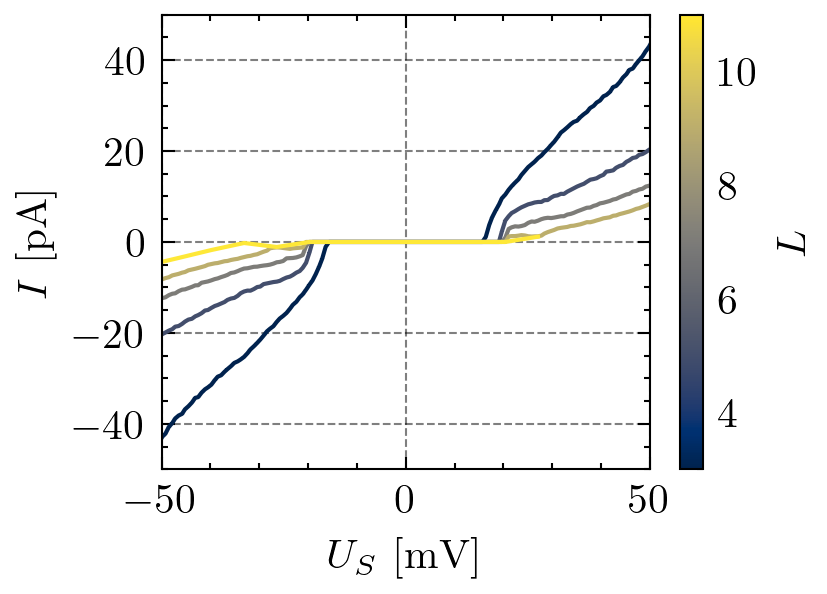

In [11]:
cmap    = plt.get_cmap('cividis')
norm    = mcolors.Normalize(vmin=min(L_VALUES),vmax=max(L_VALUES))
fig, ax = plt.subplots(dpi=300)
w, h    = fig.get_size_inches()
scale   = 0.75
fig.set_size_inches(w * scale, h * scale)
for i, N in enumerate(L_VALUES):
    df  = data[N].copy().sort_values(by='E0')
    x   = df['E0'].values*1000
    y   = df['Observable'].values*1e-6
    y_e = df['Error'].values*1e-6
    _ = ax.errorbar(x, y, y_e, color=cmap(norm(N)))
_   = ax.set_xlabel("$U_S~[\mathrm{mV}]$")
_   = ax.set_ylabel("$I~[\mathrm{pA}]$")
_   = ax.set_xlim(-50,50)
_   = ax.set_ylim(-50,50)

sm      = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar    = fig.colorbar(sm, ax=ax)
_       = cbar.set_label("$L$")

# fig.savefig(f"plots/svg/network_iv_curves.svg", transparent=True)
# fig.savefig(f"plots/pdf/network_iv_curves.pdf", transparent=False)
# fig.savefig(f"plots/png/network_iv_curves.png", transparent=False)

### Number of Jumps

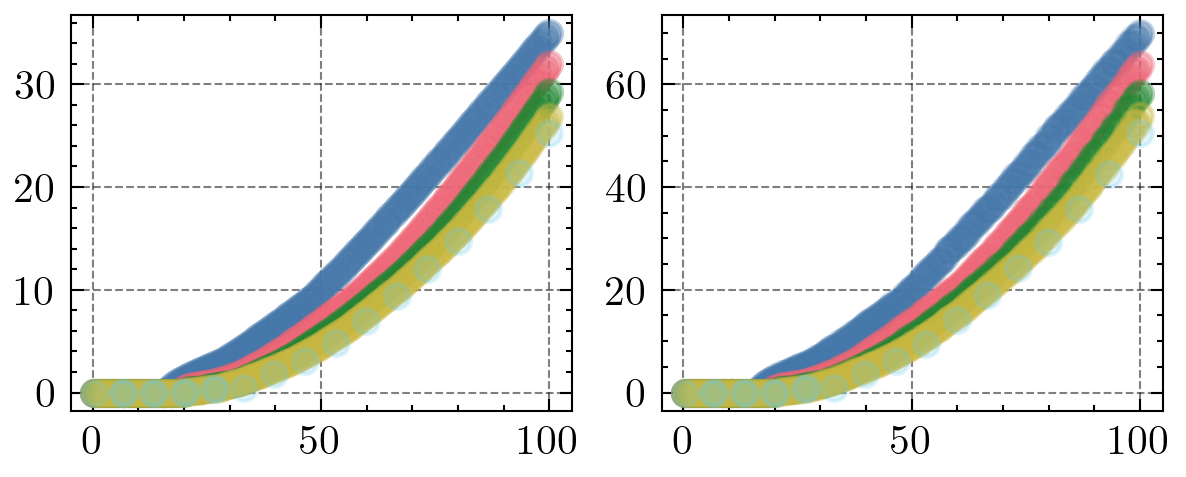

In [15]:
fig     = plt.figure(dpi=300, layout='constrained')
_       = fig.set_figwidth(fig.get_figwidth()*1.5)
_       = fig.set_figheight(fig.get_figheight()*0.8)
ax1     = fig.add_subplot(1,2,1)
ax2     = fig.add_subplot(1,2,2)
w, h    = fig.get_size_inches()
scale   = 0.75
fig.set_size_inches(w * scale, h * scale)
for i, L in enumerate(L_VALUES):
    x   = data[L]['E0'].abs().values*1000
    j   = data[L]['Jumps'].values*1e-3
    j_e = data[L]['Eq_Jumps'].values*1e-3
    _   = ax1.scatter(x, j, alpha=0.2)
    _   = ax2.scatter(x, j_e, alpha=0.2)

### Theory

In [72]:
y_theory = {}
for n in N_PARTICLES:
    if N_E == 2:
        topo = {"Nx": n, "Ny": n,
                "e_pos" : [[int((n-1)/2),0],[int((n)/2),(n-1)]],
                "electrode_type" : ['constant']*N_E}
    else:
        topo = {"Nx": n, "Ny": n,
                "e_pos" : [[int((n-1)/2),0],[0,0],[n-1,0],[0,int((n-1)/2)],
                [n-1,int((n)/2)],[0,n-1],[n-1,n-1],[int((n)/2),(n-1)]],
                "electrode_type" : ['constant']*N_E}
    sim_c = Simulation(topo)
    sim_c.build_conductance_matrix()
    sim_c.init_transfer_coeffs()
    G_eff = sim_c.get_transfer_coeffs()[0]
    I_ohm = G_eff * V_INPUT
    y_theory[n] = I_ohm